# Random Forest para fraude en PaySim

Implementacion tabular reproducible y comparable.

## Protocolo comun de evaluacion

Este notebook usa tres conjuntos separados: **64% entrenamiento, 16% validacion y 20% prueba**. Validacion sirve para seleccionar el umbral y, cuando aplica, detener el entrenamiento. Prueba se usa una sola vez para las metricas finales.

Se reportan las mismas metricas en todos los modelos: ROC-AUC, PR-AUC, precision, recall, F1, TN, FP, FN, TP, tiempo de entrenamiento e inferencia. Tambien se guardan resultados con umbral 0.5 y con el umbral que maximiza F1 en validacion.


## 1. Importaciones

In [1]:
from pathlib import Path
import json, platform, time, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
from sklearn.metrics import (average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay)
warnings.filterwarnings('ignore')
RANDOM_STATE=42
print('Python:',platform.python_version())
from sklearn.ensemble import RandomForestClassifier


Python: 3.13.9


## 2. Configuracion

In [2]:
DATA_PATH=Path('paysim.csv')
TARGET='isFraud'
TEST_SIZE=0.20
VALID_SIZE_FROM_TRAIN=0.20
SPLIT_MODE='time'  # recomendado; usa 'random' solo para replicar otro protocolo
USE_BALANCE_FEATURES=False  # conservador ante posible fuga en PaySim
DROP_FLAGGED_FRAUD=True
SAMPLE_N=None  # solo para pruebas rapidas; deja None para resultados finales
OUTPUT_DIR=Path('resultados_random_forest_paysim')
OUTPUT_DIR.mkdir(exist_ok=True)
assert SPLIT_MODE in {'time','random'}
MODEL_NAME='Random Forest'
N_ESTIMATORS=300


## 3. Carga y preparacion comun de PaySim

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro {DATA_PATH}. Ajusta DATA_PATH.')
df=pd.read_csv(DATA_PATH)
required={'step','type','amount','nameOrig','oldbalanceOrg','newbalanceOrig','nameDest','oldbalanceDest','newbalanceDest','isFraud'}
missing=sorted(required-set(df.columns))
if missing: raise ValueError(f'Faltan columnas: {missing}')
if SAMPLE_N is not None and SAMPLE_N<len(df):
    # Muestra estratificada solo para depuracion.
    fraud=df[df[TARGET]==1]; normal=df[df[TARGET]==0]
    nf=min(len(fraud),max(1,round(SAMPLE_N*len(fraud)/len(df))))
    df=pd.concat([fraud.sample(nf,random_state=RANDOM_STATE),
                  normal.sample(SAMPLE_N-nf,random_state=RANDOM_STATE)]).sort_index()
work=df.copy()
work['_original_index']=work.index
work['hour']=(work['step']-1)%24
work['day']=(work['step']-1)//24
work['dest_is_merchant']=work['nameDest'].astype(str).str.startswith('M').astype('int8')
drop=['nameOrig','nameDest']
if not USE_BALANCE_FEATURES:
    drop += ['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
else:
    work['orig_balance_error']=work['oldbalanceOrg']-work['amount']-work['newbalanceOrig']
    work['dest_balance_error']=work['oldbalanceDest']+work['amount']-work['newbalanceDest']
if DROP_FLAGGED_FRAUD and 'isFlaggedFraud' in work: drop += ['isFlaggedFraud']
work=work.drop(columns=drop,errors='ignore')
work=pd.get_dummies(work,columns=['type'],prefix='type',dtype='int8')
y=work.pop(TARGET).astype('int8')
original_index=work.pop('_original_index').to_numpy()
X=work
print('X:',X.shape,'fraudes:',int(y.sum()),'tasa:',f'{y.mean():.6%}')
display(X.head())


X: (6362620, 10) fraudes: 8213 tasa: 0.129082%


,step,amount,hour,day,dest_is_merchant,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,0,0,1,0,0,0,1,0
1,1,1864.28,0,0,1,0,0,0,1,0
2,1,181.00,0,0,0,0,0,0,0,1
3,1,181.00,0,0,0,0,1,0,0,0
4,1,11668.14,0,0,1,0,0,0,1,0


## 4. Particiones

In [4]:
from sklearn.model_selection import train_test_split
idx=np.arange(len(y))
if SPLIT_MODE=='random':
    idx_tv,idx_test=train_test_split(idx,test_size=TEST_SIZE,stratify=y,random_state=RANDOM_STATE)
    idx_train,idx_valid=train_test_split(idx_tv,test_size=VALID_SIZE_FROM_TRAIN,
        stratify=y.iloc[idx_tv],random_state=RANDOM_STATE)
else:
    order=np.argsort(X['step'].to_numpy(),kind='stable')
    cut=int(len(order)*(1-TEST_SIZE)); idx_tv,idx_test=order[:cut],order[cut:]
    cut2=int(len(idx_tv)*(1-VALID_SIZE_FROM_TRAIN)); idx_train,idx_valid=idx_tv[:cut2],idx_tv[cut2:]
X_train,y_train=X.iloc[idx_train],y.iloc[idx_train]
X_valid,y_valid=X.iloc[idx_valid],y.iloc[idx_valid]
X_test,y_test=X.iloc[idx_test],y.iloc[idx_test]
for n,z in [('train',y_train),('valid',y_valid),('test',y_test)]:
    print(f'{n}: {len(z):,} | fraudes={int(z.sum()):,} | tasa={z.mean():.6%}')
assert all(z.nunique()==2 for z in (y_train,y_valid,y_test))
np.save(OUTPUT_DIR/'indices_train.npy',original_index[idx_train])
np.save(OUTPUT_DIR/'indices_valid.npy',original_index[idx_valid])
np.save(OUTPUT_DIR/'indices_test.npy',original_index[idx_test])


train: 4,072,076 | fraudes=3,401 | tasa=0.083520%
valid: 1,018,020 | fraudes=558 | tasa=0.054812%
test: 1,272,524 | fraudes=4,254 | tasa=0.334296%


## 5. Entrenar o cargar modelo

In [5]:
TRAIN_MODEL=True
MODEL_PATH=OUTPUT_DIR/'random_forest_paysim.joblib'
if TRAIN_MODEL:
    model=RandomForestClassifier(n_estimators=N_ESTIMATORS,class_weight='balanced_subsample',
        min_samples_leaf=2,max_features='sqrt',n_jobs=-1,random_state=RANDOM_STATE)
    start=time.perf_counter(); model.fit(X_train,y_train); training_seconds=time.perf_counter()-start
    joblib.dump(model,MODEL_PATH)
else:
    start=time.perf_counter(); model=joblib.load(MODEL_PATH); training_seconds=None
print('Modelo listo:',MODEL_PATH)


Modelo listo: resultados_random_forest_paysim\random_forest_paysim.joblib


## 6. Probabilidades

In [6]:
start=time.perf_counter()
proba_valid=model.predict_proba(X_valid)[:,1]
proba_test=model.predict_proba(X_test)[:,1]
inference_seconds=time.perf_counter()-start


## 7. Metricas

In [7]:
def metricas(y_true,proba,threshold):
    pred=(proba>=threshold).astype(int); tn,fp,fn,tp=confusion_matrix(y_true,pred).ravel()
    return {'threshold':float(threshold),'roc_auc':float(roc_auc_score(y_true,proba)),
      'pr_auc':float(average_precision_score(y_true,proba)),
      'precision':float(precision_score(y_true,pred,zero_division=0)),
      'recall':float(recall_score(y_true,pred,zero_division=0)),
      'f1':float(f1_score(y_true,pred,zero_division=0)),
      'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}
def elegir_umbral(y_true,proba):
    p,r,t=precision_recall_curve(y_true,proba)
    f=2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-12)
    i=int(np.nanargmax(f)); return float(t[i]),float(f[i])
def sensibilidad(y_true,proba):
    rows=[]
    for u in np.round(np.arange(.05,1,.05),2):
        m=metricas(y_true,proba,u); rows.append(m)
    return pd.DataFrame(rows)


,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
umbral_0.5,0.500000,0.861237,0.144354,0.351194,0.383639,0.366700,1265255,3015,2622,1632
umbral_validacion,0.557956,0.861237,0.144354,0.347846,0.362482,0.355013,1265379,2891,2712,1542


Umbral elegido en validacion: 0.5579557917900942 | F1 validacion: 0.48484848484806853
              precision    recall  f1-score   support

           0     0.9979    0.9977    0.9978   1268270
           1     0.3478    0.3625    0.3550      4254

    accuracy                         0.9956   1272524
   macro avg     0.6729    0.6801    0.6764   1272524
weighted avg     0.9957    0.9956    0.9956   1272524



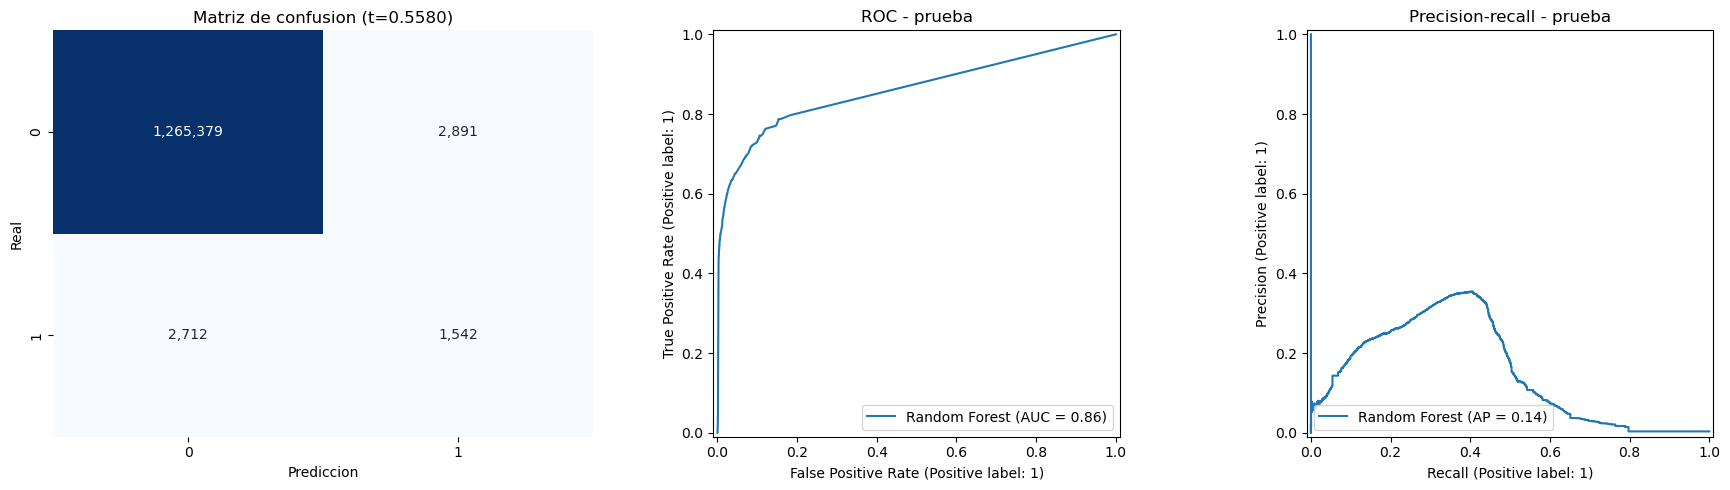

In [8]:
best_threshold,best_f1_valid=elegir_umbral(y_valid,proba_valid)
baseline=metricas(y_test,proba_test,.5)
tuned=metricas(y_test,proba_test,best_threshold)
comparison=pd.DataFrame([baseline,tuned],index=['umbral_0.5','umbral_validacion'])
display(comparison)
pred_test=(proba_test>=best_threshold).astype(int)
print('Umbral elegido en validacion:',best_threshold,'| F1 validacion:',best_f1_valid)
print(classification_report(y_test,pred_test,digits=4,zero_division=0))
fig,ax=plt.subplots(1,3,figsize=(18,5))
sns.heatmap(confusion_matrix(y_test,pred_test),annot=True,fmt=',d',cmap='Blues',cbar=False,ax=ax[0])
ax[0].set(title=f'Matriz de confusion (t={best_threshold:.4f})',xlabel='Prediccion',ylabel='Real')
RocCurveDisplay.from_predictions(y_test,proba_test,ax=ax[1],name=MODEL_NAME); ax[1].set_title('ROC - prueba')
PrecisionRecallDisplay.from_predictions(y_test,proba_test,ax=ax[2],name=MODEL_NAME); ax[2].set_title('Precision-recall - prueba')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'evaluacion_final.png',dpi=300,bbox_inches='tight'); plt.show()


## 8. Sensibilidad

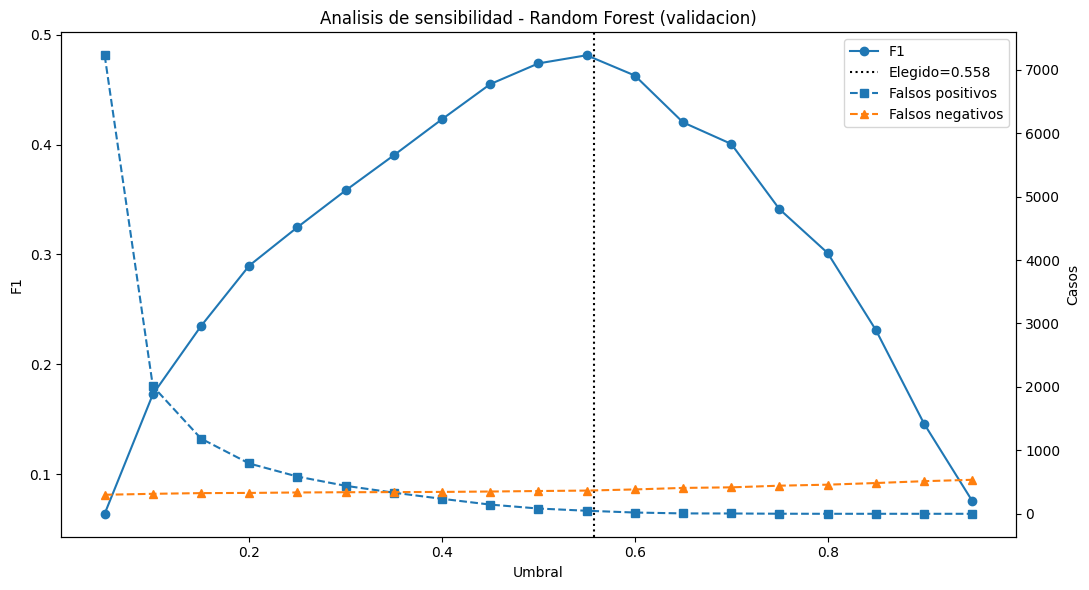

In [9]:
sens=sensibilidad(y_valid,proba_valid)
sens.to_csv(OUTPUT_DIR/'sensibilidad_validacion.csv',index=False)
fig,ax1=plt.subplots(figsize=(11,6))
l1,=ax1.plot(sens.threshold,sens.f1,marker='o',label='F1'); ax1.set(xlabel='Umbral',ylabel='F1')
ax1.axvline(best_threshold,color='black',linestyle=':',label=f'Elegido={best_threshold:.3f}')
ax2=ax1.twinx(); l2,=ax2.plot(sens.threshold,sens.fp,'--s',label='Falsos positivos'); l3,=ax2.plot(sens.threshold,sens.fn,'--^',label='Falsos negativos'); ax2.set_ylabel('Casos')
h1,labs1=ax1.get_legend_handles_labels(); h2,labs2=ax2.get_legend_handles_labels(); ax1.legend(h1+h2,labs1+labs2,loc='best')
plt.title(f'Analisis de sensibilidad - {MODEL_NAME} (validacion)'); fig.tight_layout()
plt.savefig(OUTPUT_DIR/'analisis_sensibilidad.png',dpi=300,bbox_inches='tight'); plt.show()


## 9. Importancia y exportacion

In [10]:
importance=pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)
display(importance.head(20).to_frame('importancia'))
importance.rename('importancia').to_csv(OUTPUT_DIR/'importancia.csv',header=True)
results={'model':MODEL_NAME,'data_unit':'transaccion','split_mode':SPLIT_MODE,
 'n_train':len(y_train),'n_valid':len(y_valid),'n_test':len(y_test),
 'training_seconds':training_seconds,'inference_seconds':inference_seconds,
 'metrics_threshold_0_5':baseline,'metrics_threshold_validation':tuned}
json.dump(results,open(OUTPUT_DIR/'metricas.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
pd.DataFrame({'index_original':original_index[idx_test],'y_true':y_test.to_numpy(),
 'probabilidad_fraude':proba_test,'prediccion':pred_test}).to_csv(OUTPUT_DIR/'predicciones_test.csv',index=False)
print('Guardado en',OUTPUT_DIR.resolve())


,importancia
amount,0.384976
hour,0.136969
type_TRANSFER,0.113350
step,0.085275
type_CASH_IN,0.064826
type_PAYMENT,0.063289
dest_is_merchant,0.057891
type_CASH_OUT,0.052131
day,0.039954
type_DEBIT,0.001340


Guardado en C:\Users\alomi\Documentos\Unir\ProyectoFinal\notebooks_finales\resultados_random_forest_paysim
